# MLE distributions and residual diagnostics

This notebook compares repeated-experiment MLE distributions from several likelihood variants and checks shot-level residuals against the binomial shot-noise floor.

It is designed to avoid re-reading billions of raw atom states. Residual plots use compact shot-count artifacts when available. The existing `results/2d-shot-features` artifact is built from `Z0`, so the notebook can immediately plot all 4,000 Z0 shots. To plot all 4,000 Z100 shots too, build a matching artifact with `--port Z100` and set `COUNT_ARTIFACT_DIRS['Z100']` below.

For feature-conditioned outputs the model is

```text
p0_i = A0_i + 0.5*C0_i*cos(theta_i)
p1_i = A1_i + 0.5*C1_i*cos(theta_i + dphi_signal_i + dpsi_i)

dpsi_i = beta_phi @ [s0_i, s100_i]
A0_i   = A0 + beta_A0 @ s0_i
A1_i   = A1 + beta_A1 @ s100_i
C0_i   = C0 * exp(beta_C0 @ s0_i)
C1_i   = C1 * exp(beta_C1 @ s100_i)
```

Empty beta columns are treated as zero, so the same diagnostics work for count-only, phase-only, and full feature-conditioned fits.

In [1]:
from pathlib import Path
import sys
import json

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path('..').resolve()

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
})

DATASET_DIR = REPO / 'data' / 'R80_N50_A1000000_muXStd10.0um_muVxStd10.0um_sigX100um_sigVx309um_sigXStd10.0um_sigVxStd10.0um_phi0random_sig_A0.100_f0.3000'

RESULT_FILES = {
    'count-only': REPO / 'results' / f'{DATASET_DIR.name}.pkl',
    # Add feature-conditioned outputs after fitting them, for example:
    # 'feature phase': REPO / 'results' / f'{DATASET_DIR.name}_feature_phase.pkl',
    # 'feature full': REPO / 'results' / f'{DATASET_DIR.name}_feature_full.pkl',
}

# Compact count artifacts for residual diagnostics.  The checked-in/default
# artifact is Z0 only.  Build a Z100 artifact with the command in the final cell
# if you want all-shot Z100 residuals without reading raw atom states.
FEATURE_DIR_Z0 = REPO / 'results' / '2d-shot-features'
FEATURE_DIR_Z100 = REPO / 'results' / '2d-shot-features-z100'
COUNT_ARTIFACT_DIRS = {
    'Z0': FEATURE_DIR_Z0,
    'Z100': FEATURE_DIR_Z100,
}

# Features used to reconstruct feature-conditioned nuisance corrections. These
# must match the feature sets used when fitting any feature-conditioned results.
PCA_PATH_Z0 = FEATURE_DIR_Z0 / '2d-shot-pcas.npz'
PCA_PATH_Z100 = FEATURE_DIR_Z100 / '2d-shot-pcas.npz'
SELECTED_SUMMARY_FEATURES_Z0 = ['mean_x', 'std_x']
SELECTED_SUMMARY_FEATURES_Z100 = ['mean_x', 'std_x']
N_PCS_Z0 = 0
N_PCS_Z100 = 0

TRUE_AMP = 0.1
TRUE_PHASE = 0.5
TRUE_FREQ = 0.3

## Load MLE result files

In [2]:
def load_result_table(path):
    path = Path(path)
    if not path.exists():
        print(f'missing: {path}')
        return None
    df = pd.read_pickle(path).copy()
    df['source_path'] = str(path)
    return df

results = {}
for label, path in RESULT_FILES.items():
    df = load_result_table(path)
    if df is not None:
        results[label] = df

if not results:
    raise FileNotFoundError('No result files found. Edit RESULT_FILES or run fit_mle_distributions.py first.')

summary_rows = []
for label, df in results.items():
    summary_rows.append({
        'likelihood': label,
        'n_runs': len(df),
        'amp_mean': df['amp'].mean(),
        'amp_std': df['amp'].std(ddof=1),
        'phase_mean': df['phase'].mean(),
        'phase_std': df['phase'].std(ddof=1),
        'logL_mean': df['logL'].mean() if 'logL' in df else np.nan,
        'converged': df['converged'].sum() if 'converged' in df else np.nan,
    })
summary = pd.DataFrame(summary_rows).set_index('likelihood')
display(summary)

,n_runs,amp_mean,amp_std,phase_mean,phase_std,logL_mean,converged
likelihood,,,,,,,
count-only,80,0.100044,0.001838,0.500853,0.019947,-2.256302e+07,80


## Distribution of MLE estimators

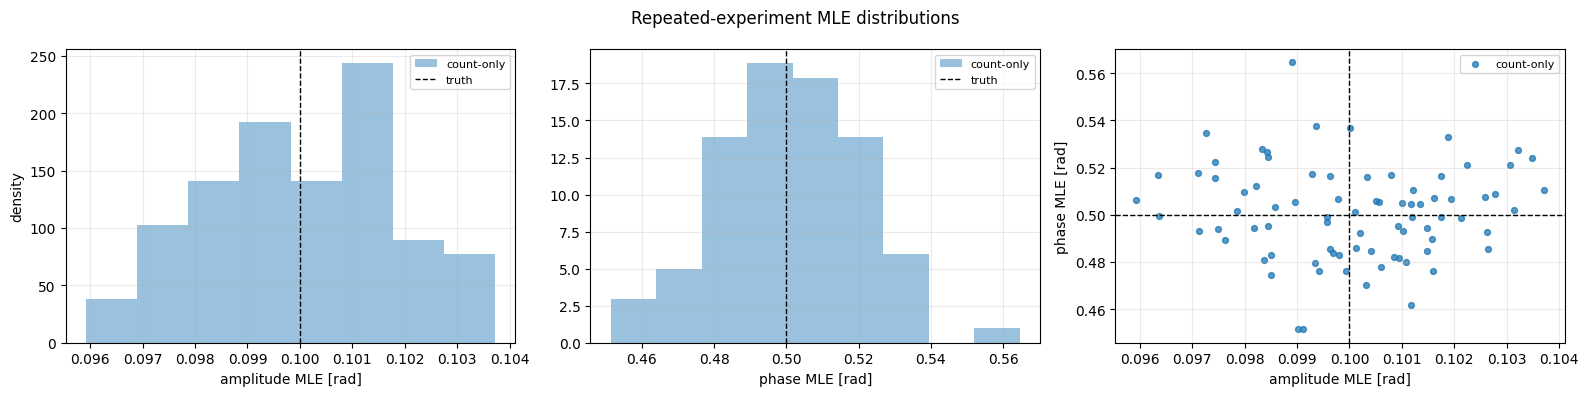

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
for label, df in results.items():
    axs[0].hist(df['amp'], bins='auto', alpha=0.45, density=True, label=label)
    axs[1].hist(df['phase'], bins='auto', alpha=0.45, density=True, label=label)
    axs[2].scatter(df['amp'], df['phase'], s=18, alpha=0.75, label=label)

axs[0].axvline(TRUE_AMP, color='k', ls='--', lw=1, label='truth')
axs[1].axvline(TRUE_PHASE, color='k', ls='--', lw=1, label='truth')
axs[2].axvline(TRUE_AMP, color='k', ls='--', lw=1)
axs[2].axhline(TRUE_PHASE, color='k', ls='--', lw=1)
axs[0].set_xlabel('amplitude MLE [rad]')
axs[1].set_xlabel('phase MLE [rad]')
axs[2].set_xlabel('amplitude MLE [rad]')
axs[2].set_ylabel('phase MLE [rad]')
axs[0].set_ylabel('density')
for ax in axs:
    ax.legend(fontsize=8)
fig.suptitle('Repeated-experiment MLE distributions')
fig.tight_layout()

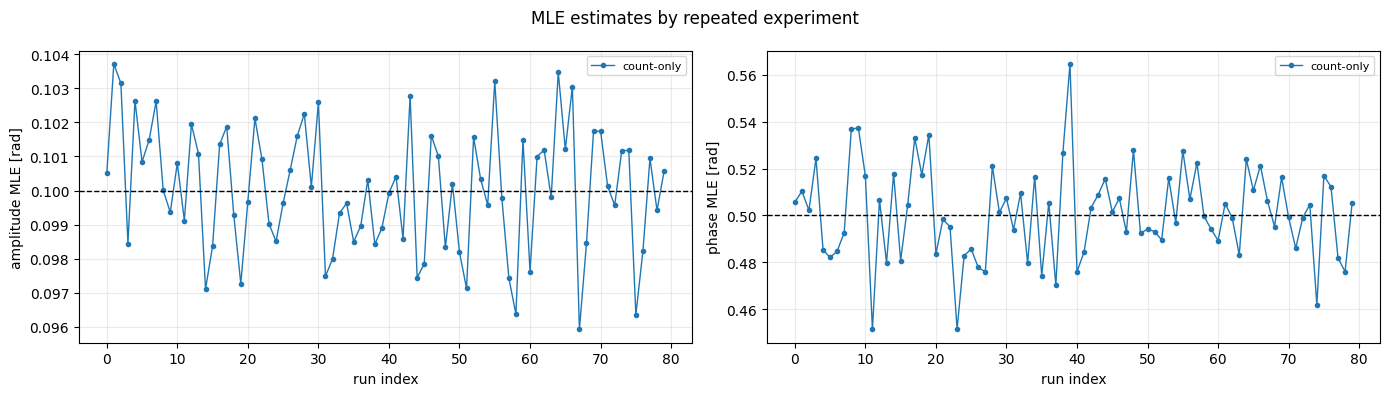

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
for label, df in results.items():
    x = np.arange(len(df))
    axs[0].plot(x, df['amp'], marker='o', ms=3, lw=1, label=label)
    axs[1].plot(x, df['phase'], marker='o', ms=3, lw=1, label=label)
axs[0].axhline(TRUE_AMP, color='k', ls='--', lw=1)
axs[1].axhline(TRUE_PHASE, color='k', ls='--', lw=1)
axs[0].set_ylabel('amplitude MLE [rad]')
axs[1].set_ylabel('phase MLE [rad]')
for ax in axs:
    ax.set_xlabel('run index')
    ax.legend(fontsize=8)
fig.suptitle('MLE estimates by repeated experiment')
fig.tight_layout()

## Compact artifact loaders

In [5]:
def load_count_artifact(artifact_dir):
    artifact_dir = Path(artifact_dir)
    required = ['manifest.json', 'shot_metadata.npz', 'ground_counts.npy', 'excited_counts.npy']
    if not artifact_dir.exists() or any(not (artifact_dir / name).exists() for name in required):
        return None
    manifest = json.loads((artifact_dir / 'manifest.json').read_text())
    metadata = np.load(artifact_dir / 'shot_metadata.npz')
    ground = np.load(artifact_dir / 'ground_counts.npy', mmap_mode='r')
    excited = np.load(artifact_dir / 'excited_counts.npy', mmap_mode='r')
    return {
        'artifact_dir': artifact_dir,
        'manifest': manifest,
        'run_id': metadata['run_id'].astype(str),
        'shot_id': np.asarray(metadata['shot_id'], dtype=int),
        'ground': ground.reshape((ground.shape[0], -1)).sum(axis=1).astype(float),
        'excited': excited.reshape((excited.shape[0], -1)).sum(axis=1).astype(float),
    }


def load_selected_features(feature_dir, selected_summary_features, n_pcs=0, pca_path=None):
    feature_dir = Path(feature_dir)
    metadata = np.load(feature_dir / 'shot_metadata.npz')
    summary_names = [str(name) for name in metadata['summary_names'].tolist()]
    summary_features = np.asarray(metadata['summary_features'], dtype=float)

    selected = list(selected_summary_features)
    if selected == ['all-summary']:
        selected = summary_names

    columns = []
    names = []
    for name in selected:
        if name not in summary_names:
            raise ValueError(f'Unknown summary feature {name!r}; available={summary_names}')
        columns.append(summary_features[:, summary_names.index(name)])
        names.append(name)

    if n_pcs:
        pca_path = Path(pca_path) if pca_path is not None else feature_dir / '2d-shot-pcas.npz'
        pca = np.load(pca_path)
        scores = np.asarray(pca['scores'], dtype=float)
        if n_pcs > scores.shape[1]:
            raise ValueError(f'Requested {n_pcs} PCs, artifact has {scores.shape[1]}')
        for j in range(n_pcs):
            columns.append(scores[:, j])
            names.append(f'PC{j + 1}_score')

    if not columns:
        return None

    X = np.column_stack(columns)
    mean = X.mean(axis=0)
    scale = X.std(axis=0)
    scale = np.where(scale > 0, scale, 1.0)
    return {
        'run_id': metadata['run_id'].astype(str),
        'shot_id': np.asarray(metadata['shot_id'], dtype=int),
        'standardized': (X - mean) / scale,
        'feature_names': tuple(names),
    }

count_artifacts = {site: load_count_artifact(path) for site, path in COUNT_ARTIFACT_DIRS.items()}
count_artifacts = {site: artifact for site, artifact in count_artifacts.items() if artifact is not None}
print('Loaded count artifacts:', {site: str(a['artifact_dir']) for site, a in count_artifacts.items()})

feature_artifacts = {}
if FEATURE_DIR_Z0.exists() and (SELECTED_SUMMARY_FEATURES_Z0 or N_PCS_Z0):
    feature_artifacts['Z0'] = load_selected_features(FEATURE_DIR_Z0, SELECTED_SUMMARY_FEATURES_Z0, N_PCS_Z0, PCA_PATH_Z0)
if FEATURE_DIR_Z100.exists() and (SELECTED_SUMMARY_FEATURES_Z100 or N_PCS_Z100):
    feature_artifacts['Z100'] = load_selected_features(FEATURE_DIR_Z100, SELECTED_SUMMARY_FEATURES_Z100, N_PCS_Z100, PCA_PATH_Z100)
print('Loaded feature artifacts:', {site: art['feature_names'] for site, art in feature_artifacts.items()})


Loaded count artifacts: {'Z0': '/home/ndm33/aispp-sims/gaussian-wavefront-spatially-resolved-inference/results/2d-shot-features'}
Loaded feature artifacts: {'Z0': ('mean_x', 'std_x')}


## Shot-level residual diagnostics

For each fitted run, this uses compact per-shot count artifacts and the simulated `Z0` laser phase metadata. The shaded band is the binomial ground-fraction shot-noise floor:

```text
sigma_shot_i = sqrt(p_i * (1 - p_i) / N_i)
```

The compact artifacts count atoms inside the normalized image window used by the feature pipeline. That is usually the desired image-summary diagnostic; if you need full-detector counts, build a separate compact full-count cache rather than reading raw atom states in the notebook.

In [6]:
def beta_vector(row, name, n_features):
    value = row.get(name, ())
    if isinstance(value, np.ndarray):
        arr = value.astype(float).ravel()
    elif isinstance(value, (list, tuple)):
        arr = np.asarray(value, dtype=float).ravel()
    elif pd.isna(value):
        arr = np.zeros(0)
    else:
        arr = np.asarray(value, dtype=float).ravel()
    if len(arr) == 0:
        return np.zeros(n_features)
    if len(arr) != n_features:
        raise ValueError(f'{name} has length {len(arr)}, expected {n_features}')
    return arr


def rows_for_run(artifact, run_idx):
    run_id = f'run_{run_idx:03d}'
    mask = artifact['run_id'] == run_id
    order = np.argsort(artifact['shot_id'][mask])
    idx = np.flatnonzero(mask)[order]
    return idx


def theta_for_run(run_idx):
    path = DATASET_DIR / f'run_{run_idx:03d}' / 'Z0' / 'data_PROB.h5'
    with h5py.File(path, 'r') as handle:
        return np.asarray(handle['phi0'][:], dtype=float)


def standardized_features_for_run(feature_artifacts, site, run_idx, n_shots):
    artifact = feature_artifacts.get(site)
    if artifact is None:
        return None
    idx = rows_for_run(artifact, run_idx)
    if len(idx) != n_shots:
        raise ValueError(f'{site} feature artifact rows for run_{run_idx:03d}: {len(idx)}; expected {n_shots}')
    return artifact['standardized'][idx]


def model_probabilities(row, theta, t, features_z0=None, features_z100=None, site='Z0', f=TRUE_FREQ):
    n = len(theta)
    if features_z0 is None:
        features_z0 = np.zeros((n, 0))
    if features_z100 is None:
        features_z100 = np.zeros((n, 0))
    n_features_z0 = features_z0.shape[1]
    n_features_z100 = features_z100.shape[1]

    if site == 'Z0':
        beta_A1 = beta_vector(row, 'beta_A1', n_features_z0)
        beta_C1 = beta_vector(row, 'beta_C1', n_features_z0)
        A_i = float(row['A1']) + (features_z0 @ beta_A1 if n_features_z0 else 0.0)
        C_i = float(row['C1']) * np.exp(features_z0 @ beta_C1 if n_features_z0 else 0.0)
        return A_i + 0.5 * C_i * np.cos(theta)

    if site == 'Z100':
        features_phase = np.column_stack([features_z0, features_z100])
        n_features_phase = features_phase.shape[1]
        beta_phi = beta_vector(row, 'beta_phi', n_features_phase)
        beta_A2 = beta_vector(row, 'beta_A2', n_features_z100)
        beta_C2 = beta_vector(row, 'beta_C2', n_features_z100)
        dpsi = features_phase @ beta_phi if n_features_phase else 0.0
        A_i = float(row['A2']) + (features_z100 @ beta_A2 if n_features_z100 else 0.0)
        C_i = float(row['C2']) * np.exp(features_z100 @ beta_C2 if n_features_z100 else 0.0)
        dphi_signal = float(row['phi0']) + float(row['As']) * np.sin(2*np.pi*f*t) + float(row['Ac']) * np.cos(2*np.pi*f*t)
        return A_i + 0.5 * C_i * np.cos(theta + dphi_signal + dpsi)

    raise ValueError(site)


def residual_table_for_results(df, count_artifacts, feature_artifacts=None, f=TRUE_FREQ):
    rows = []
    for run_idx, row in df.reset_index(drop=True).iterrows():
        theta = theta_for_run(run_idx)
        n_shots = len(theta)
        t = np.arange(n_shots, dtype=float)
        features_z0 = standardized_features_for_run(feature_artifacts, 'Z0', run_idx, n_shots)
        features_z100 = standardized_features_for_run(feature_artifacts, 'Z100', run_idx, n_shots)
        for site, artifact in count_artifacts.items():
            idx = rows_for_run(artifact, run_idx)
            if len(idx) != n_shots:
                raise ValueError(f'{site} artifact rows for run_{run_idx:03d}: {len(idx)}; expected {n_shots}')
            ground = artifact['ground'][idx]
            excited = artifact['excited'][idx]
            total = ground + excited
            pred = model_probabilities(row, theta, t, features_z0, features_z100, site=site, f=f)
            gf = ground / total
            sigma = np.sqrt(np.clip(pred * (1 - pred), 0, None) / total)
            resid = gf - pred
            rows.append(pd.DataFrame({
                'global_shot': run_idx * n_shots + np.arange(n_shots),
                'run_index': run_idx,
                'shot_id': np.arange(n_shots),
                'site': site,
                'ground_fraction': gf,
                'pred': pred,
                'resid': resid,
                'sigma_shot': sigma,
                'z_resid': resid / sigma,
                'N': total,
            }))
    return pd.concat(rows, ignore_index=True)

In [7]:
RESIDUAL_LABELS = list(results.keys())

if not count_artifacts:
    raise FileNotFoundError('No compact count artifacts found. Check COUNT_ARTIFACT_DIRS.')

residuals = {}
residual_summary_rows = []
for label in RESIDUAL_LABELS:
    print(f'Computing residuals for {label} ...')
    residuals[label] = residual_table_for_results(results[label], count_artifacts, feature_artifacts, f=TRUE_FREQ)
    for site, sub in residuals[label].groupby('site'):
        residual_summary_rows.append({
            'likelihood': label,
            'site': site,
            'n_shots': len(sub),
            'resid_std': sub['resid'].std(ddof=1),
            'mean_sigma_shot': sub['sigma_shot'].mean(),
            'resid_std_over_mean_sigma': sub['resid'].std(ddof=1) / sub['sigma_shot'].mean(),
            'z_resid_std': sub['z_resid'].std(ddof=1),
            'z_resid_mean': sub['z_resid'].mean(),
        })
residual_summary = pd.DataFrame(residual_summary_rows).set_index(['likelihood', 'site'])
display(residual_summary)

Computing residuals for count-only ...


,,n_shots,resid_std,mean_sigma_shot,resid_std_over_mean_sigma,z_resid_std,z_resid_mean
likelihood,site,,,,,,
count-only,Z0,4000,0.653717,0.000472,1386.118251,1965.771461,-58.939523


## Residuals vs shot index with shot-noise bands

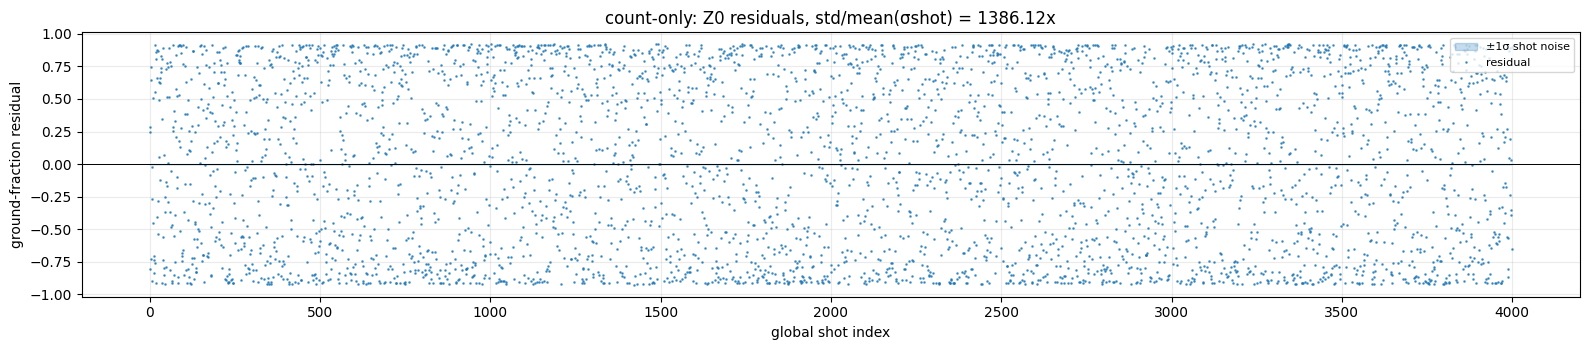

In [8]:
for label, table in residuals.items():
    sites = list(table['site'].unique())
    fig, axs = plt.subplots(len(sites), 1, figsize=(16, 3.6 * len(sites)), sharex=True)
    axs = np.atleast_1d(axs)
    for ax, site in zip(axs, sites):
        sub = table[table['site'] == site].sort_values('global_shot')
        x = sub['global_shot'].to_numpy()
        sigma = sub['sigma_shot'].to_numpy()
        resid = sub['resid'].to_numpy()
        color = 'C0' if site == 'Z0' else 'C1'
        ax.fill_between(x, -sigma, sigma, color=color, alpha=0.25, label='±1σ shot noise')
        ax.plot(x, resid, '.', ms=1.8, color=color, alpha=0.70, label='residual')
        ax.axhline(0, color='k', lw=0.7)
        ratio = resid.std(ddof=1) / sigma.mean()
        ax.set_title(f'{label}: {site} residuals, std/mean(σshot) = {ratio:.2f}x')
        ax.set_ylabel('ground-fraction residual')
        ax.legend(fontsize=8, loc='upper right')
    axs[-1].set_xlabel('global shot index')
    fig.tight_layout()

## Residual histograms

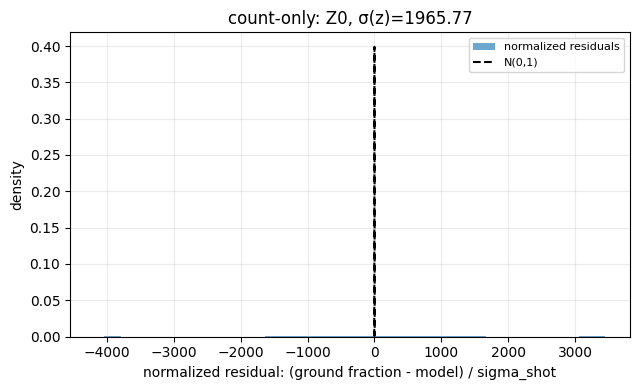

In [9]:
xx = np.linspace(-6, 6, 500)
gauss = np.exp(-0.5 * xx**2) / np.sqrt(2 * np.pi)

for label, table in residuals.items():
    sites = list(table['site'].unique())
    fig, axs = plt.subplots(1, len(sites), figsize=(6.5 * len(sites), 4), sharey=True)
    axs = np.atleast_1d(axs)
    for ax, site in zip(axs, sites):
        color = 'C0' if site == 'Z0' else 'C1'
        z = table.loc[table['site'] == site, 'z_resid'].replace([np.inf, -np.inf], np.nan).dropna()
        ax.hist(z, bins=60, density=True, alpha=0.65, color=color, label='normalized residuals')
        ax.plot(xx, gauss, 'k--', lw=1.5, label='N(0,1)')
        ax.set_title(f'{label}: {site}, σ(z)={z.std(ddof=1):.2f}')
        ax.set_xlabel('normalized residual: (ground fraction - model) / sigma_shot')
        ax.legend(fontsize=8)
    axs[0].set_ylabel('density')
    fig.tight_layout()

## How to generate comparison files and Z100 artifacts

Example commands for producing likelihood result files:

```bash
# Count-only baseline
python python-scripts/fit_mle_distributions.py \
  data/R80_N50_A1000000_muXStd10.0um_muVxStd10.0um_sigX100um_sigVx309um_sigXStd10.0um_sigVxStd10.0um_phi0random_sig_A0.100_f0.3000 \
  --output results/R80_count_only.pkl

# Feature phase-only
python python-scripts/fit_mle_distributions.py \
  data/R80_N50_A1000000_muXStd10.0um_muVxStd10.0um_sigX100um_sigVx309um_sigXStd10.0um_sigVxStd10.0um_phi0random_sig_A0.100_f0.3000 \
  --feature-dir results/2d-shot-features \
  --features mean_x std_x \
  --feature-nuisance phase \
  --output results/R80_feature_phase.pkl

# Feature phase + offset + contrast, default once --feature-dir is supplied
python python-scripts/fit_mle_distributions.py \
  data/R80_N50_A1000000_muXStd10.0um_muVxStd10.0um_sigX100um_sigVxStd10.0um_sigVxStd10.0um_phi0random_sig_A0.100_f0.3000 \
  --feature-dir results/2d-shot-features \
  --features mean_x std_x cov_x_state cov_y_state \
  --n-pcs 2 \
  --output results/R80_feature_full.pkl
```

To add all-shot Z100 residual plots without raw HDF5 scans, build a compact Z100 count artifact:

```bash
python python-scripts/build_2d_shot_features.py \
  data/R80_N50_A1000000_muXStd10.0um_muVxStd10.0um_sigX100um_sigVx309um_sigXStd10.0um_sigVxStd10.0um_phi0random_sig_A0.100_f0.3000 \
  --port Z100 \
  --output results/2d-shot-features-z100
```

Then rerun the notebook. It will automatically pick up `COUNT_ARTIFACT_DIRS['Z100']` if the directory exists.